# Data Augmentation Experiments

E5 studies training-time data augmentation while keeping the model and optimization recipe fixed.

The model configuration is full fine-tuning from ImageNet-pretrained weights. Only the training augmentation policy changes.

```mermaid
flowchart LR
    A["Fixed Full Fine-Tuning"] --> B["Baseline"]
    A --> C["ColorJitter"]
    A --> D["Rotation"]
    A --> E["ColorJitter + Rotation"]
    B --> F["Validation"]
    C --> F
    D --> F
    E --> F
    F --> G["Select Best Policy"]
    G --> H["Official Test"]
```


## Experimental Design

The fixed components are:

- ResNet-50 architecture
- ImageNet initialization
- Full fine-tuning
- Oxford-IIIT Pet train/validation split
- input resolution $224\times224$
- batch size 16
- AdamW
- learning rate $10^{-3}$
- weight decay $10^{-4}$
- cosine annealing

The experimental variable is the training augmentation policy.

The official test set is not used during policy selection.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ResNet50_Weights, resnet50

SEED = 42
DATA_ROOT = Path("../data/raw")
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed:", SEED)
print("Device:", device)


Seed: 42
Device: cuda


## Dataset Setup

In [2]:
dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class OxfordPetSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, label = self.base_dataset[self.indices[index]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

val_dataset = OxfordPetSubset(dataset_trainval, val_indices, eval_transform)
test_dataset = OxfordPetSubset(dataset_test, np.arange(len(dataset_test)), eval_transform)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_dataset))


Train samples: 2944
Validation samples: 736
Test samples: 3669


## Augmentation Policies

The baseline uses `RandomResizedCrop` and `RandomHorizontalFlip`.

Additional policies introduce moderate `ColorJitter` and/or `RandomRotation(15)`.

Validation and test transformations remain deterministic.


In [3]:
def build_train_transform(policy):
    ops = [
        transforms.RandomResizedCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
    ]

    if policy in {"color_jitter", "combined"}:
        ops.append(
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05,
            )
        )

    if policy in {"rotation", "combined"}:
        ops.append(transforms.RandomRotation(15))

    ops.extend([
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return transforms.Compose(ops)

policies = ["baseline", "color_jitter", "rotation", "combined"]


## Model and Training Functions

Every augmentation variant starts from a fresh ImageNet-pretrained ResNet-50.

The full network is trainable so that E5 evaluates augmentation independently of fine-tuning depth.


In [4]:
def build_model():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 37)
    for parameter in model.parameters():
        parameter.requires_grad = True
    return model.to(device)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [5]:
criterion = nn.CrossEntropyLoss()
checkpoint_dir = Path("../experiments/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
results_dir = Path("../experiments/results")
results_dir.mkdir(parents=True, exist_ok=True)


## Run Augmentation Experiments

Each policy is trained independently.

The checkpoint with the highest validation accuracy is saved for each policy.


In [6]:
variant_results = []
variant_histories = {}

for policy in policies:
    print(f"\n=== E5: {policy} ===")

    model = build_model()

    train_dataset = OxfordPetSubset(
        dataset_trainval,
        train_indices,
        build_train_transform(policy),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "learning_rate": [],
    }

    best_val_accuracy = 0.0
    best_epoch = 0
    checkpoint_path = checkpoint_dir / f"e5_{policy}_best.pt"

    for epoch in range(NUM_EPOCHS):
        train_loss, train_accuracy = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_accuracy = evaluate(
            model, val_loader, criterion, device
        )
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["learning_rate"].append(current_lr)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            torch.save(
                {
                    "experiment": "E5",
                    "variant": policy,
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_accuracy": val_accuracy,
                },
                checkpoint_path,
            )

        scheduler.step()

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2%} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2%} | "
            f"LR: {current_lr:.2e}"
        )

    variant_histories[policy] = history
    variant_results.append({
        "experiment": "E5",
        "variant": policy,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "checkpoint": str(checkpoint_path),
    })

e5_validation_results = pd.DataFrame(variant_results)
e5_validation_results



=== E5: baseline ===
Epoch [01/30] | Train Loss: 2.4216 | Train Acc: 32.51% | Val Loss: 1.7097 | Val Acc: 48.10% | LR: 1.00e-03
Epoch [02/30] | Train Loss: 1.7027 | Train Acc: 49.66% | Val Loss: 1.4296 | Val Acc: 56.39% | LR: 9.97e-04
Epoch [03/30] | Train Loss: 1.4363 | Train Acc: 56.66% | Val Loss: 1.2664 | Val Acc: 64.40% | LR: 9.89e-04
Epoch [04/30] | Train Loss: 1.3467 | Train Acc: 59.41% | Val Loss: 1.1745 | Val Acc: 66.03% | LR: 9.76e-04
Epoch [05/30] | Train Loss: 1.1792 | Train Acc: 64.40% | Val Loss: 0.8497 | Val Acc: 75.00% | LR: 9.57e-04
Epoch [06/30] | Train Loss: 1.0524 | Train Acc: 69.33% | Val Loss: 0.8207 | Val Acc: 76.63% | LR: 9.33e-04
Epoch [07/30] | Train Loss: 0.9820 | Train Acc: 69.67% | Val Loss: 0.8950 | Val Acc: 76.77% | LR: 9.05e-04
Epoch [08/30] | Train Loss: 0.8849 | Train Acc: 73.06% | Val Loss: 0.7447 | Val Acc: 77.58% | LR: 8.72e-04
Epoch [09/30] | Train Loss: 0.8313 | Train Acc: 74.56% | Val Loss: 0.8197 | Val Acc: 77.17% | LR: 8.35e-04
Epoch [10/30] |

,experiment,variant,best_epoch,best_val_accuracy,checkpoint
0,E5,baseline,28,0.908967,../experiments/checkpoints/e5_baseline_best.pt
1,E5,color_jitter,26,0.917120,../experiments/checkpoints/e5_color_jitter_bes...
2,E5,rotation,30,0.911685,../experiments/checkpoints/e5_rotation_best.pt
3,E5,combined,30,0.907609,../experiments/checkpoints/e5_combined_best.pt


## Select the Best Augmentation Policy

The policy with the highest validation accuracy is selected.

The test set remains untouched during this selection step.


In [7]:
best_policy_row = e5_validation_results.sort_values(
    "best_val_accuracy", ascending=False
).iloc[0]

best_policy = best_policy_row["variant"]

print("Selected policy:", best_policy)
print(
    "Best validation accuracy:",
    f"{best_policy_row['best_val_accuracy']:.2%}",
)


Selected policy: color_jitter
Best validation accuracy: 91.71%


## Validation Curves

The validation curves provide diagnostic evidence about how the augmentation policies affect convergence and generalization.


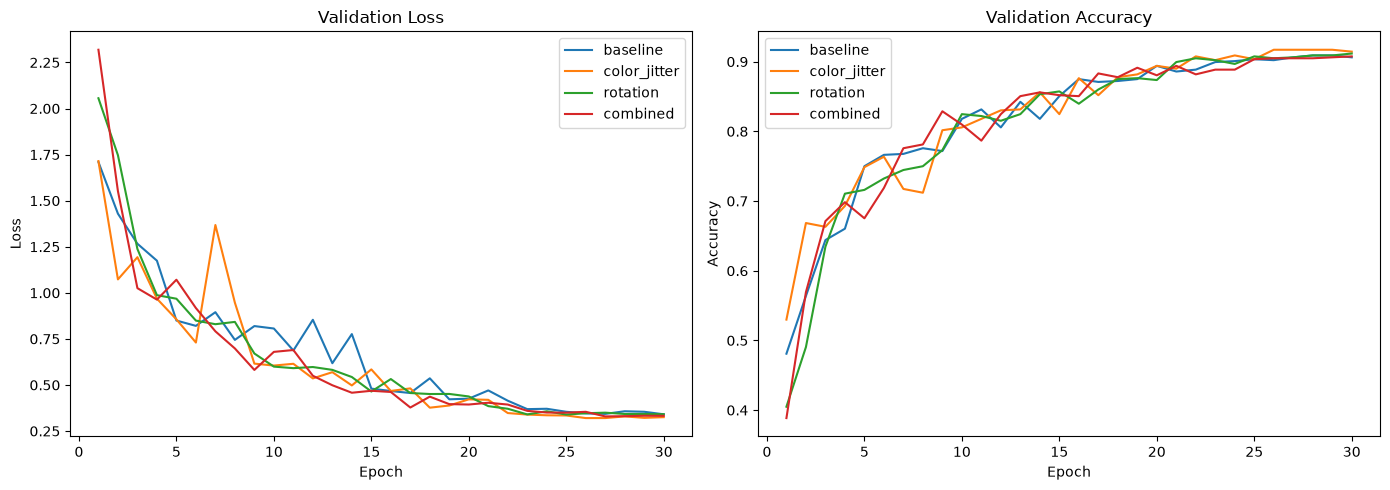

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for policy, history in variant_histories.items():
    epochs = range(1, NUM_EPOCHS + 1)
    axes[0].plot(epochs, history["val_loss"], label=policy)
    axes[1].plot(epochs, history["val_accuracy"], label=policy)

axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## Final Evaluation on the Test Set

Only the validation-selected augmentation policy is evaluated on the official test set.


In [9]:
best_checkpoint = torch.load(
    best_policy_row["checkpoint"],
    map_location=device,
)

best_model = build_model()
best_model.load_state_dict(best_checkpoint["model_state_dict"])

test_loss, test_accuracy = evaluate(
    best_model,
    test_loader,
    criterion,
    device,
)

print("Selected policy:", best_policy)
print(f"E5 Test Loss: {test_loss:.4f}")
print(f"E5 Test Accuracy: {test_accuracy:.2%}")


Selected policy: color_jitter
E5 Test Loss: 0.4724
E5 Test Accuracy: 87.63%


## E5 Final Result

The selected augmentation configuration is saved as the E5 result. Intermediate validation results remain available for later comparison.


In [10]:
e5_result = pd.DataFrame([{
    "experiment": "E5",
    "model": "ResNet-50",
    "initialization": "ImageNet",
    "trainable_params": sum(p.numel() for p in best_model.parameters() if p.requires_grad),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": int(best_policy_row["best_epoch"]),
    "best_val_accuracy": float(best_policy_row["best_val_accuracy"]),
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "strategy": "Full Fine-Tuning",
    "augmentation": best_policy,
}])

e5_result


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,test_accuracy,test_loss,strategy,augmentation
0,E5,ResNet-50,ImageNet,23583845,30,16,0.001,0.0001,26,0.91712,0.876261,0.472353,Full Fine-Tuning,color_jitter


In [11]:
e5_result.to_csv(results_dir / "e5_data_augmentation.csv", index=False)

results_path = results_dir / "experiment_results.csv"
if results_path.exists():
    existing = pd.read_csv(results_path)
    existing = existing[existing["experiment"] != "E5"]
    combined = pd.concat([existing, e5_result], ignore_index=True)
else:
    combined = e5_result.copy()

combined.to_csv(results_path, index=False)
combined


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy,augmentation
0,E0,ResNet-50,Random,23583845,30,16,0.001,0.0001,30,0.338315,2.317437,0.288907,2.500295,NaN,NaN
1,E1,ResNet-50,ImageNet,75813,30,16,0.001,0.0001,16,0.937500,0.226684,0.911420,0.292235,Feature Extraction,NaN
2,E2,ResNet-50,ImageNet,15040549,30,16,0.001,0.0001,21,0.947011,0.214195,0.911965,0.366784,Layer4 + FC Fine-Tuning,NaN
3,E3,ResNet-50,ImageNet,22138917,30,16,0.001,0.0001,26,0.929348,0.265825,0.879531,0.468232,Layer3 + Layer4 Fine-Tuning,NaN
4,E4,ResNet-50,ImageNet,23583845,30,16,0.001,0.0001,28,0.913043,0.343463,0.872172,0.486822,Full Fine-Tuning,NaN
5,E5,ResNet-50,ImageNet,23583845,30,16,0.001,0.0001,26,0.917120,NaN,0.876261,0.472353,Full Fine-Tuning,color_jitter


# Conclusions

E5 isolates data augmentation as an experimental variable. The best policy is selected using validation accuracy and evaluated once on the official test set.

The next phase studies optimization hyperparameters.
